# loading and reprocessing data 

In [ ]:
import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler
import joblib  # Pour sauvegarder les objets de prétraitement

# Configuration pour la reproductibilité
np.random.seed(42)

# Chargement des données
dataset = pd.read_csv("/home/sarah/Desktop/gender-classifier-using-voice/PFE/PRECISION90.csv")
X = dataset.iloc[:, 1:-1].values
y = dataset.iloc[:, -1].values

# Gestion des données manquantes
imputer = SimpleImputer(missing_values=np.nan, strategy='mean')
X = imputer.fit_transform(X)

# Encodage des données catégorielles
encoder = LabelEncoder()
y = encoder.fit_transform(y)

# Normalisation des caractéristiques
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Data preparation completed successfully.")

# MODELLING (Training + Test + evaluation metrics)
# Unsupervised algorithms : GMM and kMEANS

# 1- GMM

/home/sarah/myproject/myenv/lib/python3.9/site-packages/sklearn/mixture/_base.py:268: ConvergenceWarning: Initialization 1 did not converge. Try different init parameters, or increase max_iter, tol or check for degenerate data.
  warnings.warn(


Accuracy for men: 91.93%
Accuracy for women: 83.67%
Overall accuracy: 87.80%
Test duration: 0.7612 seconds


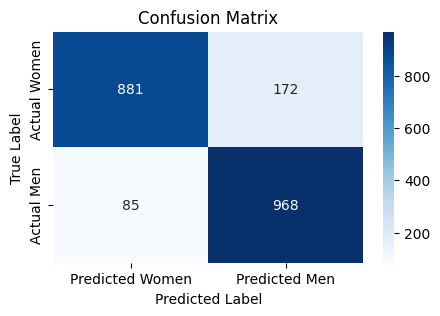

Precision for women: 0.912008281573499
Precision for men: 0.8491228070175438
Recall for women: 0.8366571699905033
Recall for men: 0.9192782526115859
F1-score for women: 0.8727092620108965
F1-score for men: 0.8828089375284998
Average precision: 0.8805655442955214
Average recall: 0.8779677113010447
Average F1-score: 0.8777590997696981


In [7]:

import numpy as np
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
import time

# Séparation des données en fonction des labels
X_men = X_scaled[y == 1]
X_women = X_scaled[y == 0]

# Séparation en ensembles d'entraînement et de test
X_men_train, X_men_test = train_test_split(X_men, test_size=0.25, random_state=42)
X_women_train, X_women_test = train_test_split(X_women, test_size=0.25, random_state=42)

# Création et entraînement des modèles GMM avec initialisation des moyennes

gmm_men = GaussianMixture(n_components=88, covariance_type= 'tied', tol= 0.0002477756589953289, reg_covar=0.0002209708760171981, random_state=42)
gmm_women = GaussianMixture(n_components=88, covariance_type= 'tied', tol= 0.0002477756589953289, reg_covar=0.0002209708760171981, random_state=42)

# Entraînement des modèles GMM
gmm_men.fit(X_men_train)
gmm_women.fit(X_women_train)

# Début du chronométrage
start_time = time.time()

# Classification des données de test
def classify_gender(X_test, gmm_men, gmm_women):
    men_scores = gmm_men.score_samples(X_test)
    women_scores = gmm_women.score_samples(X_test)
    predictions = np.where(men_scores > women_scores, 1, 0)
    return predictions

# Classification des ensembles de test hommes et femmes
men_predictions = classify_gender(X_men_test, gmm_men, gmm_women)
women_predictions = classify_gender(X_women_test, gmm_men, gmm_women)

# Fin du chronométrage
end_time = time.time()
test_duration = end_time - start_time

# Labels réels pour les ensembles de test
y_men_test = np.ones(len(X_men_test))
y_women_test = np.zeros(len(X_women_test))

# Prédictions combinées et labels réels combinés
y_true = np.concatenate([y_men_test, y_women_test])
y_pred = np.concatenate([men_predictions, women_predictions])

# Calcul de la précision
men_accuracy = np.mean(men_predictions == 1)
women_accuracy = np.mean(women_predictions == 0)
overall_accuracy = (men_accuracy + women_accuracy) / 2

print(f"Accuracy for men: {men_accuracy * 100:.2f}%")
print(f"Accuracy for women: {women_accuracy * 100:.2f}%")
print(f"Overall accuracy: {overall_accuracy * 100:.2f}%")
print(f"Test duration: {test_duration:.4f} seconds")

# Calcul de la matrice de confusion
cm = confusion_matrix(y_true, y_pred)

# Affichage de la matrice de confusion
plt.figure(figsize=(5, 3))
sns.heatmap(cm, annot=True, fmt="d", cmap='Blues', xticklabels=['Predicted Women', 'Predicted Men'], yticklabels=['Actual Women', 'Actual Men'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()


# Calcul des métriques de précision, rappel, et F1-score pour chaque classe
precision_women = precision_score(y_true, y_pred, pos_label=0)
precision_men = precision_score(y_true, y_pred, pos_label=1)
recall_women = recall_score(y_true, y_pred, pos_label=0)
recall_men = recall_score(y_true, y_pred, pos_label=1)
f1_women = f1_score(y_true, y_pred, pos_label=0)
f1_men = f1_score(y_true, y_pred, pos_label=1)

# Calcul des métriques moyennes
avg_precision = (precision_women + precision_men) / 2
avg_recall = (recall_women + recall_men) / 2
avg_f1 = (f1_women + f1_men) / 2

print(f"Precision for women: {precision_women:}")
print(f"Precision for men: {precision_men:}")
print(f"Recall for women: {recall_women:}")
print(f"Recall for men: {recall_men:}")
print(f"F1-score for women: {f1_women:}")
print(f"F1-score for men: {f1_men:}")
print(f"Average precision: {avg_precision:}")
print(f"Average recall: {avg_recall:}")
print(f"Average F1-score: {avg_f1:}")



# 2- KMeans

Accuracy for men: 72.65%
Accuracy for women: 63.44%
Overall accuracy: 68.04%
Test duration: 0.0036 seconds


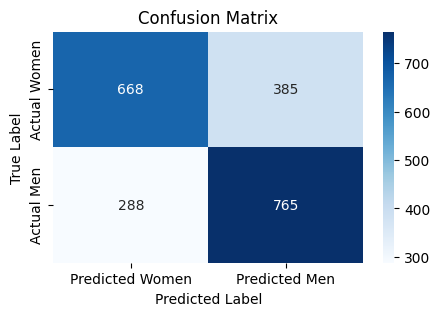

Precision for women: 0.698744769874477
Precision for men: 0.6652173913043479
Recall for women: 0.6343779677113011
Recall for men: 0.7264957264957265
F1-score for women: 0.6650074664011946
F1-score for men: 0.6945074897866546
Average precision: 0.6819810805894124
Average recall: 0.6804368471035138
Average F1-score: 0.6797574780939246


In [14]:
from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import time

# Séparation des données en fonction des labels
X_men = X_scaled[y == 1]
X_women = X_scaled[y == 0]

# Séparation en ensembles d'entraînement et de test
X_men_train, X_men_test = train_test_split(X_men, test_size=0.25, random_state=42)
X_women_train, X_women_test = train_test_split(X_women, test_size=0.25, random_state=42)

# Création et entraînement des modèles KMeans

kmeans_men = KMeans(n_clusters=1,     random_state=42)
kmeans_women = KMeans(n_clusters=1,   random_state=42)

# Entraînement des modèles KMeans
kmeans_men.fit(X_men_train)
kmeans_women.fit(X_women_train)

# Début du chronométrage
start_time = time.time()

# Classification des données de test
def classify_gender_kmeans(X_test, kmeans_men, kmeans_women):
    men_distances = kmeans_men.transform(X_test).flatten()
    women_distances = kmeans_women.transform(X_test).flatten()
    predictions = np.where(men_distances < women_distances, 1, 0)
    return predictions

# Classification des ensembles de test hommes et femmes
men_predictions = classify_gender_kmeans(X_men_test, kmeans_men, kmeans_women)
women_predictions = classify_gender_kmeans(X_women_test, kmeans_men, kmeans_women)

# Fin du chronométrage
end_time = time.time()
test_duration = end_time - start_time

# Calcul de la précision
men_accuracy = np.mean(men_predictions == 1)
women_accuracy = np.mean(women_predictions == 0)
overall_accuracy = (men_accuracy + women_accuracy) / 2

print(f"Accuracy for men: {men_accuracy * 100:.2f}%")
print(f"Accuracy for women: {women_accuracy * 100:.2f}%")
print(f"Overall accuracy: {overall_accuracy * 100:.2f}%")
print(f"Test duration: {test_duration:.4f} seconds")

# Affichage de la matrice de confusion
y_men_test = np.ones(len(X_men_test))
y_women_test = np.zeros(len(X_women_test))

# Prédictions combinées et labels réels combinés
y_true = np.concatenate([y_men_test, y_women_test])
y_pred = np.concatenate([men_predictions, women_predictions])

# Calcul de la matrice de confusion
cm = confusion_matrix(y_true, y_pred)

# Affichage de la matrice de confusion
plt.figure(figsize=(5, 3))
sns.heatmap(cm, annot=True, fmt="d", cmap='Blues', xticklabels=['Predicted Women', 'Predicted Men'], yticklabels=['Actual Women', 'Actual Men'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# Calcul des métriques de précision, rappel, et F1-score pour chaque classe
precision_women = precision_score(y_true, y_pred, pos_label=0)
precision_men = precision_score(y_true, y_pred, pos_label=1)
recall_women = recall_score(y_true, y_pred, pos_label=0)
recall_men = recall_score(y_true, y_pred, pos_label=1)
f1_women = f1_score(y_true, y_pred, pos_label=0)
f1_men = f1_score(y_true, y_pred, pos_label=1)

# Calcul des métriques moyennes
avg_precision = (precision_women + precision_men) / 2
avg_recall = (recall_women + recall_men) / 2
avg_f1 = (f1_women + f1_men) / 2

print(f"Precision for women: {precision_women:}")
print(f"Precision for men: {precision_men:}")
print(f"Recall for women: {recall_women:}")
print(f"Recall for men: {recall_men:}")
print(f"F1-score for women: {f1_women:}")
print(f"F1-score for men: {f1_men:}")
print(f"Average precision: {avg_precision:}")
print(f"Average recall: {avg_recall:}")
print(f"Average F1-score: {avg_f1:}")



Accuracy for men: 72.65%
Accuracy for women: 63.44%
Overall accuracy: 68.04%
Test duration: 0.0070 seconds


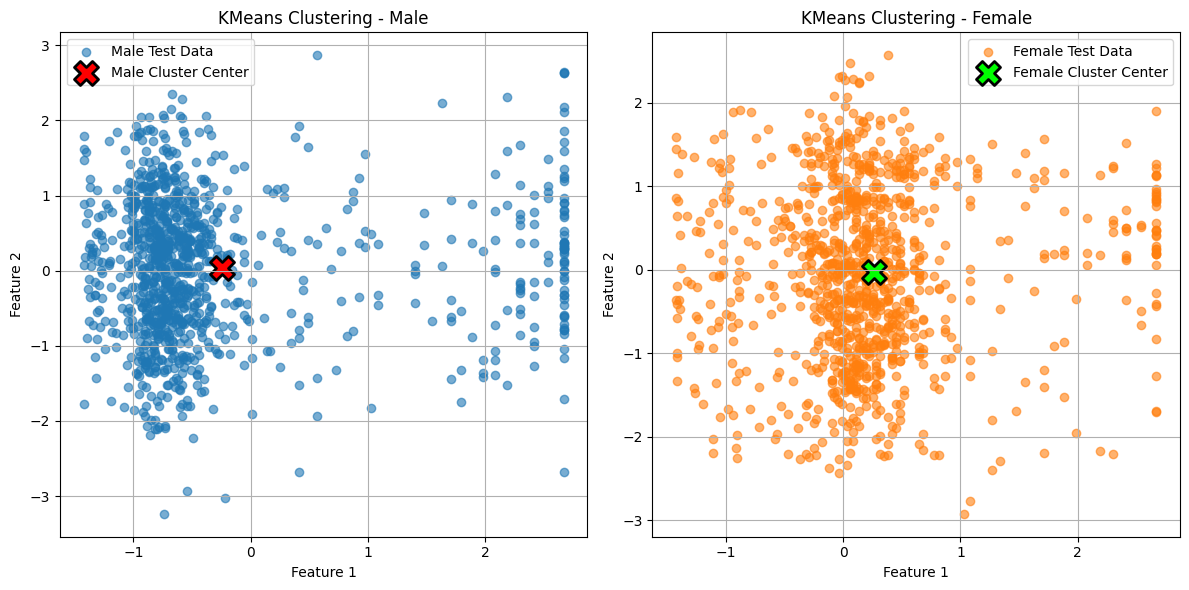

In [3]:
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import time

# Séparation des données en fonction des labels
X_men = X_scaled[y == 1]
X_women = X_scaled[y == 0]

# Séparation en ensembles d'entraînement et de test
X_men_train, X_men_test = train_test_split(X_men, test_size=0.25, random_state=42)
X_women_train, X_women_test = train_test_split(X_women, test_size=0.25, random_state=42)

# Création et entraînement des modèles KMeans
kmeans_men = KMeans(n_clusters=1, random_state=42)
kmeans_women = KMeans(n_clusters=1, random_state=42)

# Entraînement des modèles KMeans
kmeans_men.fit(X_men_train)
kmeans_women.fit(X_women_train)

# Début du chronométrage
start_time = time.time()

# Classification des données de test
def classify_gender_kmeans(X_test, kmeans_men, kmeans_women):
    men_distances = kmeans_men.transform(X_test).flatten()
    women_distances = kmeans_women.transform(X_test).flatten()
    predictions = np.where(men_distances < women_distances, 1, 0)
    return predictions

# Classification des ensembles de test hommes et femmes
men_predictions = classify_gender_kmeans(X_men_test, kmeans_men, kmeans_women)
women_predictions = classify_gender_kmeans(X_women_test, kmeans_men, kmeans_women)

# Fin du chronométrage
end_time = time.time()
test_duration = end_time - start_time

# Calcul de la précision
men_accuracy = np.mean(men_predictions == 1)
women_accuracy = np.mean(women_predictions == 0)
overall_accuracy = (men_accuracy + women_accuracy) / 2

print(f"Accuracy for men: {men_accuracy * 100:.2f}%")
print(f"Accuracy for women: {women_accuracy * 100:.2f}%")
print(f"Overall accuracy: {overall_accuracy * 100:.2f}%")
print(f"Test duration: {test_duration:.4f} seconds")

# Couleurs personnalisées
men_test_color = '#1f77b4' 
women_test_color = '#ff7f0e'  
men_center_color = '#ff0000'  
women_center_color = '#00ff00'  

# Visualisation des clusters et des centres
plt.figure(figsize=(12, 6))

# Visualisation des hommes
plt.subplot(1, 2, 1)
plt.scatter(X_men_test[:, 0], X_men_test[:, 1], c=men_test_color, label='Male Test Data', alpha=0.6)
plt.scatter(kmeans_men.cluster_centers_[:, 0], kmeans_men.cluster_centers_[:, 1], c=men_center_color, marker='X', s=300, edgecolors='black', linewidths=2, label='Male Cluster Center')
plt.title('KMeans Clustering - Male')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)

# Visualisation des femmes
plt.subplot(1, 2, 2)
plt.scatter(X_women_test[:, 0], X_women_test[:, 1], c=women_test_color, label='Female Test Data', alpha=0.6)
plt.scatter(kmeans_women.cluster_centers_[:, 0], kmeans_women.cluster_centers_[:, 1], c=women_center_color, marker='X', s=300, edgecolors='black', linewidths=2, label='Female Cluster Center')
plt.title('KMeans Clustering - Female')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()